In [2]:
import pandas as pd
df = pd.read_csv("/home/alejo/Projects/University/Fundamentos-de-la-Ciencia-de-Datos/Archivos/archivo_2.csv", encoding='latin-1')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_145997/2518454664.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peliculas['Rango años'] = pd.cut(df['release_year'], bins=[1947, 1957, 1967, 1977, 1987, 1997, 2007, 2017], labels=['1947-1957','1957-1967','1967-1977','1977-1987','1987-1997','1997-2007','2007-2017'])


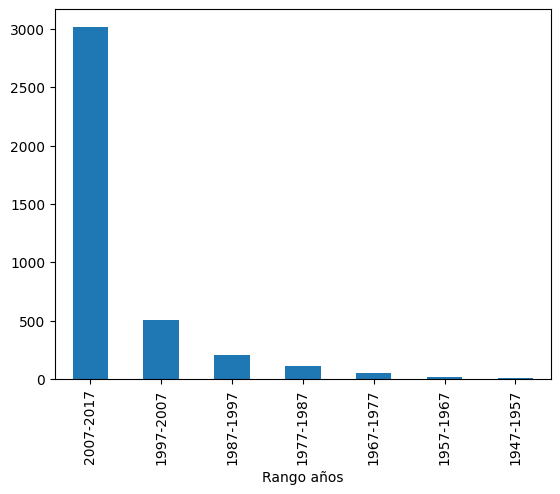

In [13]:
#Numero de peliculas segun su año de lanzamiento.
import pandas as pd
import matplotlib.pyplot as plt
peliculas = df[df['type'] == 'Movie']
peliculas['Rango años'] = pd.cut(df['release_year'], bins=[1947, 1957, 1967, 1977, 1987, 1997, 2007, 2017], labels=['1947-1957','1957-1967','1967-1977','1977-1987','1987-1997','1997-2007','2007-2017'])
cant_por_rango = peliculas['Rango años'].value_counts()
cant_por_rango.plot(kind='bar')
plt.show()


/tmp/ipykernel_145997/1283964734.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv_show['Rango años'] = pd.cut(tv_show['release_year'], bins=[1947, 1957, 1967, 1977, 1987, 1997, 2007, 2017], labels=['1947-1957','1957-1967','1967-1977','1977-1987','1987-1997','1997-2007','2007-2017'])


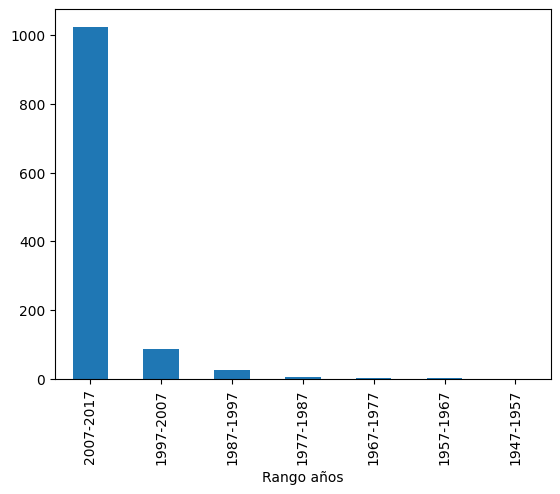

In [15]:
#Numero de TV show segun su año de lanzamiento.
import pandas as pd
import matplotlib.pyplot as plt
tv_show = df[df['type'] == 'TV Show']
tv_show['Rango años'] = pd.cut(tv_show['release_year'], bins=[1947, 1957, 1967, 1977, 1987, 1997, 2007, 2017], labels=['1947-1957','1957-1967','1967-1977','1977-1987','1987-1997','1997-2007','2007-2017'])
cant_por_rango = tv_show['Rango años'].value_counts()
cant_por_rango.plot(kind='bar')
plt.show()


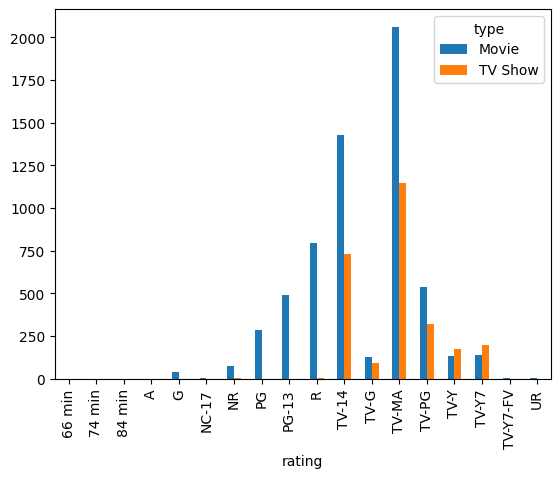

In [18]:
import pandas as pd
tabla_rating = pd.crosstab(df['rating'], df['type'])
tabla_rating.plot(kind='bar')
plt.show()

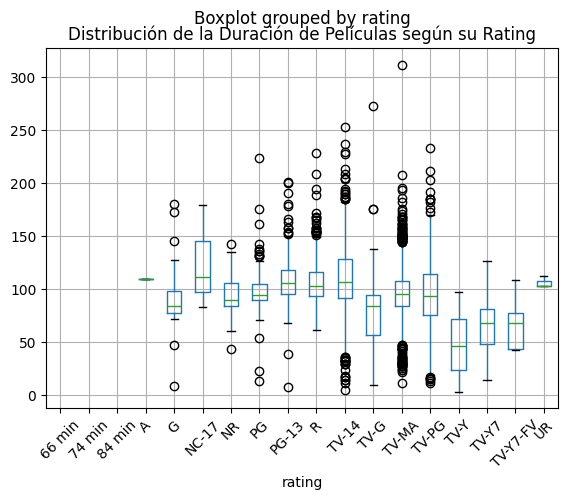

In [27]:
#Relación entre rating y duración de las peliculas y/o series.
import matplotlib.pyplot as plt
import pandas as pd

# Filtramos solo películas
peliculas = df[df['type'] == 'Movie'].copy()

# Limpiamos la duración: sacamos la palabra " min" y la convertimos a número entero
peliculas['duration_num'] = (
    peliculas['duration'].str.replace(' min', '').astype(float)
)

peliculas.boxplot(
    column='duration_num', by='rating'
)

plt.title('Distribución de la Duración de Películas según su Rating')
plt.xticks(rotation=45)
plt.show()

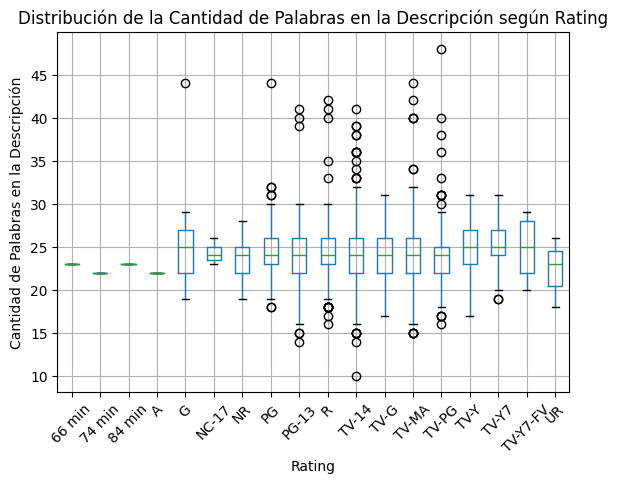

In [14]:
#Relación entre tamaño de descripción con rating.
import matplotlib.pyplot as plt
import pandas as pd

peliculas = df[df['type'] == 'Movie'].copy()

peliculas['cant_palabras'] = (peliculas['description'].str.split().str.len())

peliculas.boxplot(column='cant_palabras', by='rating')

plt.title(
    'Distribución de la Cantidad de Palabras en la Descripción según Rating'
)
plt.suptitle('') 
plt.xlabel('Rating')
plt.ylabel('Cantidad de Palabras en la Descripción')
plt.xticks(rotation=45)
plt.show()

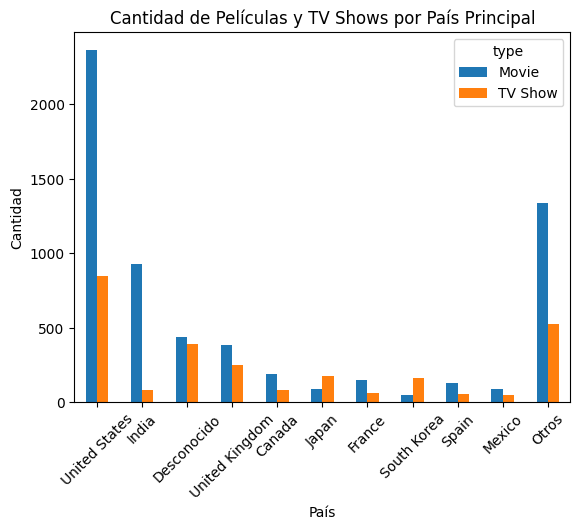

In [ ]:
#Numero de peliculas y TV Shows por pais.
import matplotlib.pyplot as plt
import pandas as pd

df_paises = df.copy()

df_paises['country_main'] = (df_paises['country'].fillna('Desconocido').str.split(',').str[0].str.strip())

tabla_pais = pd.crosstab(df_paises['country_main'], df_paises['type'])

tabla_pais['Total'] = tabla_pais['Movie'] + tabla_pais['TV Show']
tabla_pais = tabla_pais.sort_values(by='Total', ascending=False)
tabla_pais = tabla_pais.drop(columns=['Total'])

top_n = 10
paises_top = tabla_pais.head(top_n).copy()
paises_otros = tabla_pais.tail(len(tabla_pais) - top_n).sum(numeric_only=True)
paises_top.loc['Otros'] = paises_otros #Este .loc[] lo usamos para que cree como fila y no como columna la categoria "otros".

paises_top.plot(kind='bar')

plt.title('Cantidad de Películas y TV Shows por País Principal')
plt.xlabel('País')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

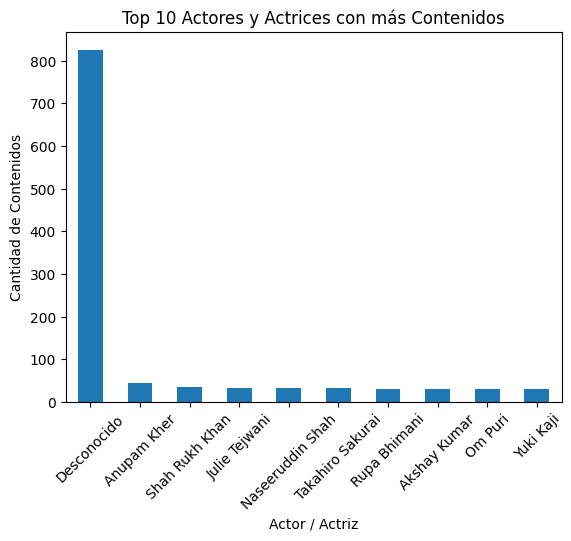

In [ ]:
#Cantidad de contenidos por actor.
import matplotlib.pyplot as plt
import pandas as pd

df_actores = df.copy()

df_actores['actores'] = (df_actores['cast'].fillna('Desconocido').str.split(','))

df_expandido = df_actores.explode('actores') 

df_expandido['actores'] = df_expandido['actores'].str.strip()

top_actores = df_expandido['actores'].value_counts().head(10)

top_actores.plot(kind='bar')

plt.title('Top 10 Actores y Actrices con más Contenidos')
plt.xlabel('Actor / Actriz')
plt.ylabel('Cantidad de Contenidos')
plt.xticks(rotation=45)
plt.show()